<a href="https://colab.research.google.com/github/Friendchie/Tesis/blob/main/ViTransf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Transformer con el dataset WM811K Wafer Map

Este script te guiará sobre cómo configurar un Vision Transformer para procesar tu dataset de mapas de obleas. Primero, necesitamos cargar y comprender la estructura de tus datos.

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Define la ruta (ajusta 'TuCarpeta' al nombre real)
path = '/content/drive/MyDrive/Colab Notebooks/TESIS/LSWMD.pkl'

# Cargar el archivo
df = pd.read_pickle(path)

# 1. Exploracion de datos

In [ ]:
# Mostrar las primeras filas y la estructura
print(df.info())
df.head()

# Inspeccionar el DataFrame
print("\nPrimeras 5 filas del DataFrame:")
display(df.head())

print("\nInformación del DataFrame:")
df.info()

print("\nÚltimas 5 filas del DataFrame:")
display(df.tail())

print("\nColumnas del DF:")
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB
None

Primeras 5 filas del DataFrame:


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB

Últimas 5 filas del DataFrame:


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
811452,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,23.0,[[Test]],[[Edge-Ring]]
811453,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,...",600.0,lot47542,24.0,[[Test]],[[Edge-Loc]]
811454,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,25.0,[[Test]],[[Edge-Ring]]
811455,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,...",600.0,lot47543,1.0,[],[]
811456,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47543,2.0,[],[]



Columnas del DF:


Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')

## Eploracion de etiquetas y limpieza de datos

In [ ]:
# Define una función auxiliar para extraer la cadena de texto de listas anidadas o listas simples
# y manejar listas vacías.
def extract_single_failure_type(val):
    # Si el valor es un numpy.ndarray, convertirlo a una lista para procesamiento consistente
    if isinstance(val, np.ndarray):
        val = val.tolist()

    if isinstance(val, list):
      # recorre el valor del registro para tomar el primer valor de la doble cadena y asi poder obtener
      # el str
        if len(val) > 0:
            if isinstance(val[0], list) and len(val[0]) > 0:
                return val[0][0]
            else: # Maneja casos como ['none'] o ['Training']
                return val[0]
        else: # Maneja la lista vacía '[]'
            return 'none' # Asigna 'none' a las listas vacías
    return val # Devuelve el valor tal cual si no es una lista

# Aplica la función a la columna 'failureType' para limpiarla en el lugar
df['failureType'] = df['failureType'].apply(extract_single_failure_type)

# Aplica la función a la columna 'trianTestLabel' para limpiarla en el lugar
df['trianTestLabel'] = df['trianTestLabel'].apply(extract_single_failure_type)

# Ahora, crea 'failureNum' basándose en el 'failureType' limpio (que ahora es una cadena de texto)
df['failureNum'] = df['failureType']

mapping_type={'Center':0,'Donut':1,'Edge-Loc':2,'Edge-Ring':3,'Loc':4,'Random':5,'Scratch':6,'Near-full':7,'none':8}
# Usa .replace directamente en la Serie df['failureNum'], pasando el diccionario
df['failureNum'] = df['failureNum'].replace(mapping_type)

df.tail()

/tmp/ipykernel_7449/2367130680.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['failureNum'] = df['failureNum'].replace(mapping_type)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType,failureNum
811452,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,23.0,Test,Edge-Ring,3
811453,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,...",600.0,lot47542,24.0,Test,Edge-Loc,2
811454,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,25.0,Test,Edge-Ring,3
811455,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,...",600.0,lot47543,1.0,none,none,8
811456,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47543,2.0,none,none,8


# Exploracion de dimensiones de mapa

In [ ]:
# 2. Add wafermapDim column because waferMap dim is different each other.
def find_dim(x):
    dim0 = np.size(x, axis=0)
    dim1 = np.size(x, axis=1)
    return dim0, dim1
df['waferMapDim']= df['waferMap'].apply(lambda x: find_dim(x))
df.head(5)

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType,failureNum,waferMapDim
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,Training,none,8,"(45, 48)"
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,Training,none,8,"(45, 48)"
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,Training,none,8,"(45, 48)"
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,Training,none,8,"(45, 48)"
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,Training,none,8,"(45, 48)"


# Segmentacion de etiquetas

In [ ]:
# df_withlabel.shape[0]: Total de mapas con etiquetas.
# df_withpattern.shape[0]: Total de mapas con fallos reales (tus clases objetivo).
# df_nonpattern.shape[0]: Total de mapas sin fallos.

df_withlabel = df[(df['failureType']!=0)]
df_withlabel =df_withlabel.reset_index() #labeled index.
df_withpattern = df_withlabel[(df_withlabel['failureType'] != 'none')]
df_withpattern = df_withpattern.reset_index() #patterned index.
df_nonpattern = df_withlabel[(df_withlabel['failureType'] == 'none')] #nonpatterned index
df_withlabel.shape[0], df_withpattern.shape[0], df_nonpattern.shape[0]

(811457, 25519, 785938)

In [ ]:
df_withlabel['waferMapDim'].value_counts()

,count
waferMapDim,
"(32, 29)",108687
"(25, 27)",64083
"(49, 39)",39323
"(26, 26)",30078
"(30, 34)",29513
...,...
"(21, 24)",1
"(15, 3)",1
"(21, 17)",1


In [ ]:
df_nonpattern.head()

,index,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType,failureNum,waferMapDim
0,0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,Training,none,8,"(45, 48)"
1,1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,Training,none,8,"(45, 48)"
2,2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,Training,none,8,"(45, 48)"
3,3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,Training,none,8,"(45, 48)"
4,4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,Training,none,8,"(45, 48)"


In [ ]:
df_withpattern.head()

,level_0,index,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType,failureNum,waferMapDim
0,19,19,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,20.0,Training,Loc,4,"(45, 48)"
1,36,36,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2460.0,lot2,12.0,Training,Edge-Loc,2,"(53, 58)"
2,37,37,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2460.0,lot2,13.0,Training,Edge-Loc,2,"(53, 58)"
3,38,38,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2460.0,lot2,14.0,Training,Edge-Loc,2,"(53, 58)"
4,39,39,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2460.0,lot2,15.0,Training,Edge-Loc,2,"(53, 58)"


## Distribucion de los errores mapeados

In [ ]:
display(df_withpattern['failureType'].value_counts())

,count
failureType,
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555
Near-full,149


In [ ]:
display(df_nonpattern['failureType'].value_counts())

,count
failureType,
none,785938


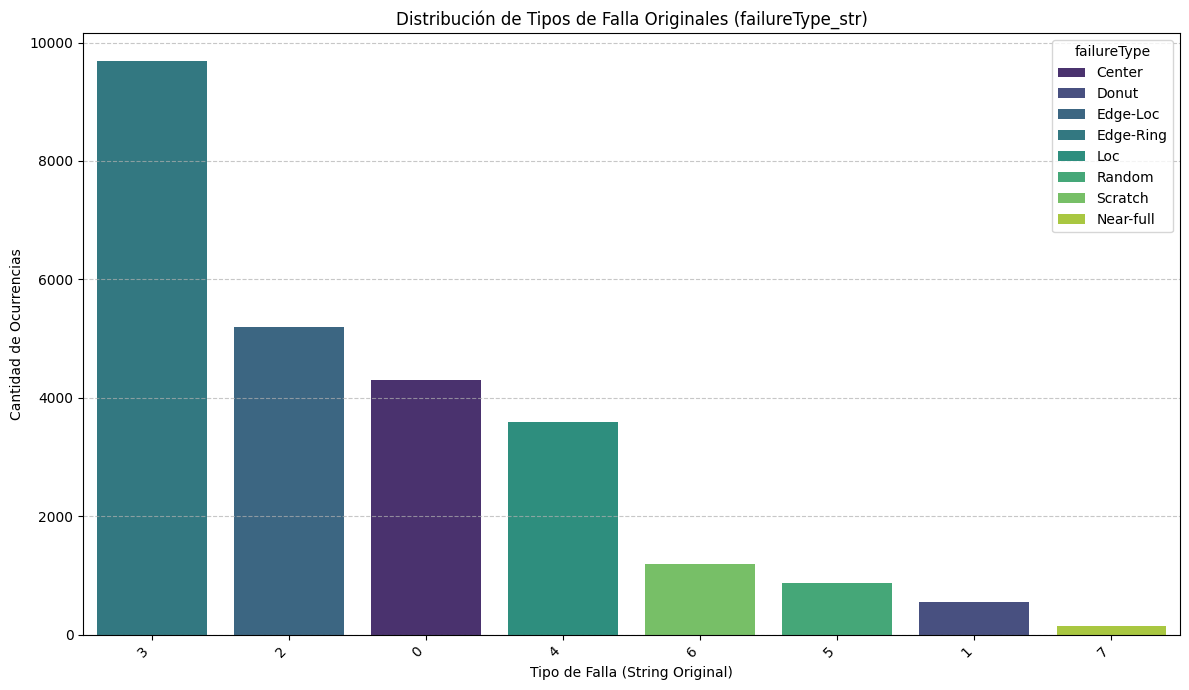

In [ ]:
from matplotlib import legend
# Plot the distribution of these string failure types
plt.figure(figsize=(12, 7))
sns.countplot(x='failureNum', data=df_withpattern, palette='viridis', hue='failureType', legend=True, order=df_withpattern['failureNum'].value_counts().index)
plt.title('Distribución de Tipos de Falla Originales (failureType_str)')
plt.xlabel('Tipo de Falla (String Original)')
plt.ylabel('Cantidad de Ocurrencias')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Distribucion de etiquetas

calculo para el % de etiqueta segun el grupo al que pertenece

In [ ]:
len(df['waferMap'])-df_withlabel.shape[0], df_withpattern.shape[0], df_nonpattern.shape[0]

(0, 25519, 785938)

Gráfico de distribucion de patrones y etiquetas

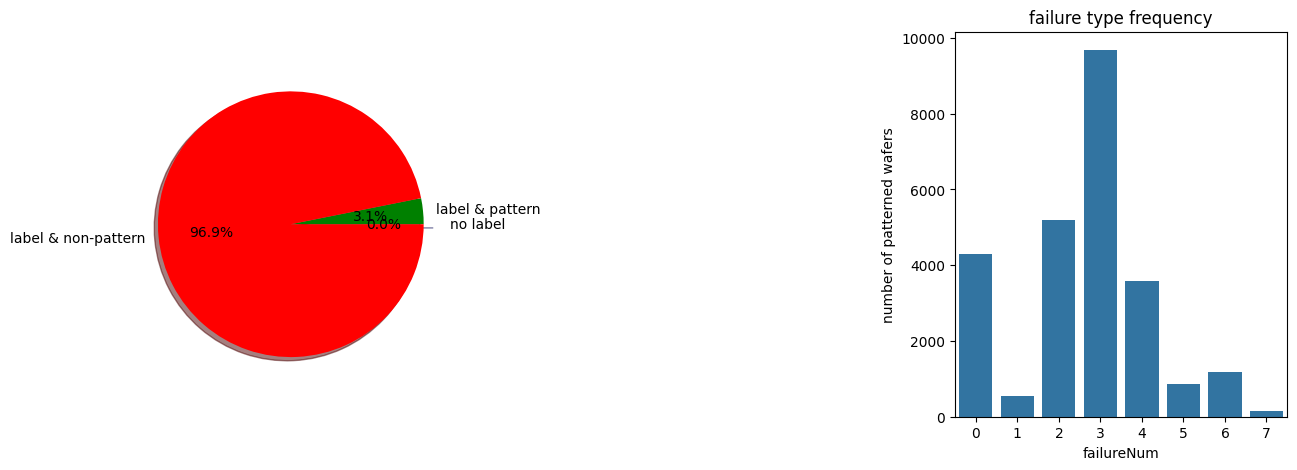

In [ ]:
fig,ax = plt.subplots(1,2, figsize = (15,5))
colors = ['blue', 'green', 'red']
num_wafers=[len(df['waferMap'])-df_withlabel.shape[0], df_withpattern.shape[0], df_nonpattern.shape[0]]
labels = ['no label', 'label & pattern', 'label & non-pattern']
ax[0].pie(num_wafers, explode=(0.1,0,0), labels = labels, colors = colors, autopct = '%1.1f%%', shadow=True)
sns.countplot(x='failureNum', data=df_withpattern, ax=ax[1])
ax[1].set_title("failure type frequency")
ax[1].set_ylabel("number of patterned wafers")
plt.subplots_adjust(wspace = 1.5)
plt.show()

# Conteo de registros para saber cuantos hay de test y training

In [ ]:
display(df_nonpattern['trianTestLabel'].value_counts())

,count
trianTestLabel,
none,638507
Test,110701
Training,36730


# Manejo de valores nulos

## Conteo de valores nulos en DF sin patrones de error

In [ ]:
print("Valores nulos por columna en df_nonpattern:")
print(df_nonpattern.isna().sum())

Valores nulos por columna en df_nonpattern:
index             0
waferMap          0
dieSize           0
lotName           0
waferIndex        0
trianTestLabel    0
failureType       0
failureNum        0
waferMapDim       0
dtype: int64


## Conteo de valores nulos en DF con patrones de error

In [ ]:
print("Valores nulos por columna en df_nonpattern:")
print(df_withpattern.isna().sum())

Valores nulos por columna en df_nonpattern:
level_0           0
index             0
waferMap          0
dieSize           0
lotName           0
waferIndex        0
trianTestLabel    0
failureType       0
failureNum        0
waferMapDim       0
dtype: int64


# 2. Preprocesamiento de Datos para Vision Transformer

Para alimentar un Vision Transformer, necesitamos convertir los mapas de obleas (que son matrices) en tensores de imagen y prepararlos para el modelo. Esto generalmente implica:

*   **Transformaciones**: Redimensionar, normalizar, y añadir una dimensión de canal (si es necesario).
*   **Aumentación de Datos**: Aplicar técnicas como rotaciones y flips para incrementar la diversidad del conjunto de entrenamiento, especialmente para las clases minoritarias.
*   **Dataset personalizado**: Crear una clase `Dataset` de PyTorch para manejar la carga de datos y las transformaciones.
*   **DataLoader**: Utilizar `DataLoader` para cargar datos por lotes y aplicar las transformaciones.

In [ ]:
# Re-define mapping_type to ensure it's available in this cell's scope for clarity.
mapping_type={'Center':0,'Donut':1,'Edge-Loc':2,'Edge-Ring':3,'Loc':4,'Random':5,'Scratch':6,'Near-full':7,'none':8}
num_classes = len(mapping_type)
print(f"Número de clases de falla: {num_classes}")
print(f"Mapeo de etiquetas: {mapping_type}")


# 1. Combinar df_nonpattern y df_withpattern para crear un único DataFrame con datos etiquetados.
# Este combined_df ya no se usará directamente para train_df, pero podría ser útil para val_df si no se modifica.
# Para la limpieza, seguiremos usando combined_df para asegurar que los datos sean válidos antes de la división.
combined_df = pd.concat([df_nonpattern, df_withpattern], ignore_index=True)

# 2. Limpiar datos: eliminar filas donde 'waferMap' no es una matriz válida
#    y donde 'failureNum' (nuestra etiqueta) no sea un valor numérico válido.
initial_len = len(combined_df)
combined_df_cleaned = combined_df[
    combined_df['waferMap'].apply(lambda x: isinstance(x, np.ndarray) and x.ndim > 0)
].copy()


print(f'nueva cantidad{len(combined_df_cleaned)}')



# Asegurarse de que failureNum sea un entero válido, no una lista vacía u otro tipo inesperado.
combined_df_cleaned = combined_df_cleaned[
    combined_df_cleaned['failureNum'].apply(lambda x: isinstance(x, (int, np.integer)))
].copy()


print(f'nueva cantidad{len(combined_df_cleaned)}')



# Filter combined_df_cleaned to only include 'Training' or 'Test' labels
# The 'trianTestLabel' column should now contain simple strings 'Training' or 'Test' thanks to previous cleaning.
combined_df_cleaned = combined_df_cleaned[
    combined_df_cleaned['trianTestLabel'].isin(['Training', 'Test'])
].copy()

print(f"Se eliminaron {initial_len - len(combined_df_cleaned)} filas inválidas durante la limpieza.")

Número de clases de falla: 9
Mapeo de etiquetas: {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-full': 7, 'none': 8}
nueva cantidad811457
nueva cantidad811457
Se eliminaron 638507 filas inválidas durante la limpieza.


In [ ]:
# Definir transformaciones para los mapas de obleas
# Los modelos ViT preentrenados suelen esperar imágenes de 224x224 píxeles con 3 canales (RGB).
# Los mapas de obleas son imágenes en escala de grises, por lo que expandiremos a 3 canales.
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.ToPILImage(), # Convertir numpy array a PIL Image
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Redimensionar a 224x224
    transforms.ToTensor(), # Convertir a tensor de PyTorch (escala [0, 1])
    # Los mapas de obleas son escala de grises. Para ViT preentrenado, replicar 3 veces el canal.
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0]==1 else x),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalizar con ImageNet stats
])

In [ ]:
class WaferMapDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        wafer_map = self.dataframe.iloc[idx]['waferMap']
        label = self.dataframe.iloc[idx]['failureNum'] # Usar failureNum directamente

        # 1. Asegurar formato de matriz
        if wafer_map.ndim == 2:
            wafer_map = wafer_map.copy()
        elif wafer_map.ndim == 3 and wafer_map.shape[0] == 1:
            wafer_map = wafer_map[0].copy()
        else:
            raise ValueError("Formato de waferMap inesperado.")

        # 2. EL ARREGLO MÁGICO: Expandir el contraste de 0,1,2 a 0,127,255
        wafer_map = (wafer_map / 2.0 * 255).astype(np.uint8)

        # 3. Aplicar transformaciones (ToPILImage ahora sí verá grises y blancos)
        if self.transform:
            wafer_map = self.transform(wafer_map)

        return wafer_map, torch.tensor(label, dtype=torch.long)

In [ ]:
def augment_data(df, target_count=2000):
    """
    Aumenta las clases minoritarias usando rotaciones y flips, y acota las clases
    mayoritarias al `target_count` especificado para balancear el dataset.
    INCLUYE LÍMITE DE SEGURIDAD para evitar sobreajuste en clases críticas.
    """
    df_processed = pd.DataFrame()

    # Obtener todos los tipos de falla únicos, incluyendo 'none'
    all_failure_types = df['failureType'].unique()

    for ftype in all_failure_types:
        df_class = df[df['failureType'] == ftype].copy()
        current_count = len(df_class)

        if current_count > target_count:
            # Downsample: tomar una muestra aleatoria de target_count
            print(f"Downsampling clase {ftype}: {current_count} -> {target_count}")
            df_processed = pd.concat([df_processed, df_class.sample(n=target_count, random_state=42)])

        elif current_count < target_count:
            # Añadir las muestras originales existentes primero
            df_processed = pd.concat([df_processed, df_class])

            # LÍMITE DE SEGURIDAD: No multiplicar la clase por más de 10 veces su tamaño original
            max_multiplier = 10
            needed = min(target_count - current_count, current_count * max_multiplier)

            print(f"Upsampling clase {ftype}: {current_count} -> Aumentando a aprox. {current_count + needed}")

            if needed <= 0:
                continue

            new_rows = []
            # Muestrear con reemplazo para obtener suficientes originales para la aumentación
            samples_to_transform = df_class.sample(n=needed, replace=True, random_state=42)

            for i in range(len(samples_to_transform)):
                wafer = samples_to_transform.iloc[i]['waferMap']
                # Aplicar una transformación aleatoria (Rotación o Flip)
                transform_type = np.random.choice(['rot90', 'rot180', 'rot270', 'flip_lr', 'flip_ud'])

                if transform_type == 'rot90':
                    new_wafer = np.rot90(wafer, 1)
                elif transform_type == 'rot180':
                    new_wafer = np.rot90(wafer, 2)
                elif transform_type == 'rot270':
                    new_wafer = np.rot90(wafer, 3)
                elif transform_type == 'flip_lr':
                    new_wafer = np.fliplr(wafer)
                else: # flip_ud
                    new_wafer = np.flipud(wafer)

                # Crear la nueva fila manteniendo la metadata original
                new_row = samples_to_transform.iloc[i].copy()
                new_row['waferMap'] = new_wafer
                new_rows.append(new_row)

            df_processed = pd.concat([df_processed, pd.DataFrame(new_rows)], ignore_index=True)

        else: # current_count == target_count
            print(f"Clase {ftype}: {current_count} (ya está balanceada)")
            df_processed = pd.concat([df_processed, df_class])

    # Mezclar (shuffle) el DataFrame final para evitar sesgos por orden
    return df_processed.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# Crear instancias del Dataset y DataLoader
# Dividir en conjuntos de entrenamiento y validación utilizando 'trianTestLabel'

# 1. Filtramos los datos de entrenamiento según las etiquetas del dataset original
# Tomamos todos los que tienen fallos reales (Training: 17,625)
df_train_defects = df_withpattern[df_withpattern['trianTestLabel'] == 'Training']

# 2. Seleccionamos aleatoriamente la misma cantidad de la clase 'none'
# del grupo de entrenamiento, acotando a un máximo de 2000 muestras.
df_train_none = df_nonpattern[df_nonpattern['trianTestLabel'] == 'Training'].sample(
    n=min(len(df_train_defects), 2000), # Acotamos las muestras 'none' a un máximo de 2000
    random_state=42
)

# 3. Concatenamos para crear el set de entrenamiento inicial balanceado
df_train_balanced = pd.concat([df_train_defects, df_train_none])

# 4. Mezclamos (shuffle) para que el modelo no aprenda el orden
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Aplicamos el aumento de datos a las clases minoritarias
# Recomendación para Tesis: un target de 5,000 para balancear sin explotar la memoria
# Se ajusta el target_count a 1000 según la solicitud del usuario.
train_df = augment_data(df_train_balanced, target_count=2000)

# Verificación de resultados del conjunto de entrenamiento final
print("\n--- Distribución Final del Dataset de Entrenamiento (con aumento de datos) ---")
print(f"Total de muestras de entrenamiento: {len(train_df)}")
print(train_df['failureType'].value_counts())

val_df = combined_df_cleaned[combined_df_cleaned['trianTestLabel'] == 'Test'].copy()

# Reducir el val_df al 50%
val_df = val_df.sample(frac=0.30, random_state=42).reset_index(drop=True)

train_dataset = WaferMapDataset(train_df, transform=transform)
val_dataset = WaferMapDataset(val_df, transform=transform)

BATCH_SIZE = 80
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nNúmero de muestras de entrenamiento: {len(train_dataset)}")
print(f"Número de muestras de validación: {len(val_dataset)}")

# Verificar un lote
for images, labels in train_loader:
    print(f"\nForma de las imágenes en un lote: {images.shape}")
    print(f"Forma de las etiquetas en un lote: {labels.shape}")
    print(f"Tipo de datos de las etiquetas: {labels.dtype}")
    break

Downsampling clase Center: 3462 -> 2000
Upsampling clase Scratch: 500 -> Aumentando a aprox. 2000
Upsampling clase Loc: 1620 -> Aumentando a aprox. 2000
Downsampling clase Edge-Ring: 8554 -> 2000
Downsampling clase Edge-Loc: 2417 -> 2000
Clase none: 2000 (ya está balanceada)
Upsampling clase Random: 609 -> Aumentando a aprox. 2000
Upsampling clase Donut: 409 -> Aumentando a aprox. 2000
Upsampling clase Near-full: 54 -> Aumentando a aprox. 594

--- Distribución Final del Dataset de Entrenamiento (con aumento de datos) ---
Total de muestras de entrenamiento: 16594
failureType
Donut        2000
Loc          2000
Center       2000
Scratch      2000
Random       2000
none         2000
Edge-Ring    2000
Edge-Loc     2000
Near-full     594
Name: count, dtype: int64

Número de muestras de entrenamiento: 16594
Número de muestras de validación: 35578

Forma de las imágenes en un lote: torch.Size([80, 3, 224, 224])
Forma de las etiquetas en un lote: torch.Size([80])
Tipo de datos de las etiquetas

# 3. Definición del Modelo Vision Transformer (ViT)

Utilizaremos un modelo Vision Transformer preentrenado de `torchvision.models` y adaptaremos su capa de salida para nuestro problema de clasificación con `num_classes` categorías.

In [ ]:
# Cargar un modelo ViT preentrenado (por ejemplo, ViT-Base con parche de 16x16)
model = models.vit_b_16(pretrained=True)

# Reemplazar la capa de clasificación (head) para nuestro número de clases
# La capa 'head' es un clasificador lineal para ViT
# Corrección: Acceder a la capa de clasificación a través de model.heads.head
model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

# Mover el modelo a la GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Modelo Vision Transformer cargado y modificado:")
print(model)
print(f"\nEl modelo se ejecutará en: {device}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 69.7MB/s]


Modelo Vision Transformer cargado y modificado:
VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps

# 4. Configuración del Entrenamiento y Bucle

Aquí definimos la función de pérdida, el optimizador y el bucle de entrenamiento para ajustar el modelo a tus datos.

In [ ]:
# 1. Calculamos la cantidad real de cada clase en el dataset (antes del aumento extremo)
# Usamos num_classes=9 para asegurarnos de tener el tamaño correcto
conteo_clases = df_train_balanced['failureNum'].value_counts().sort_index().values

# 2. Calculamos los pesos inversamente proporcionales (clase menor = mayor peso)
pesos = 1.0 / torch.tensor(conteo_clases, dtype=torch.float)
pesos = pesos / pesos.sum() * num_classes # Normalizamos
pesos = pesos.to(device)

# 3. Aplicamos los pesos a la función de pérdida
criterion = nn.CrossEntropyLoss(weight=pesos)

# Definir la función de pérdida y el optimizador
criterion = nn.CrossEntropyLoss()
#optimizer = optim.AdamW(model.parameters(), lr=1e-4) etiquetado porque el lr destruia los pesos del modelo preentrenado
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
# Bucle de entrenamiento
num_epochs = 5




Iniciando entrenamiento...
    Época [1/5], Lote [100/208], Pérdida: 0.5289, Precisión: 84.11%
    Época [1/5], Lote [200/208], Pérdida: 0.3347, Precisión: 89.62%
Época 1 Finalizada, Pérdida de Entrenamiento: 0.3254, Precisión de Entrenamiento: 89.87%
    Pérdida de Validación: 0.1313, Precisión de Validación: 96.05%
    Época [2/5], Lote [100/208], Pérdida: 0.0858, Precisión: 97.16%
    Época [2/5], Lote [200/208], Pérdida: 0.0771, Precisión: 97.48%
Época 2 Finalizada, Pérdida de Entrenamiento: 0.0773, Precisión de Entrenamiento: 97.47%
    Pérdida de Validación: 0.1221, Precisión de Validación: 96.30%
    Época [3/5], Lote [100/208], Pérdida: 0.0411, Precisión: 98.59%
    Época [3/5], Lote [200/208], Pérdida: 0.0440, Precisión: 98.49%
Época 3 Finalizada, Pérdida de Entrenamiento: 0.0448, Precisión de Entrenamiento: 98.46%
    Pérdida de Validación: 0.1635, Precisión de Validación: 95.24%
    Época [4/5], Lote [100/208], Pérdida: 0.0305, Precisión: 98.95%
    Época [4/5], Lote [200/2

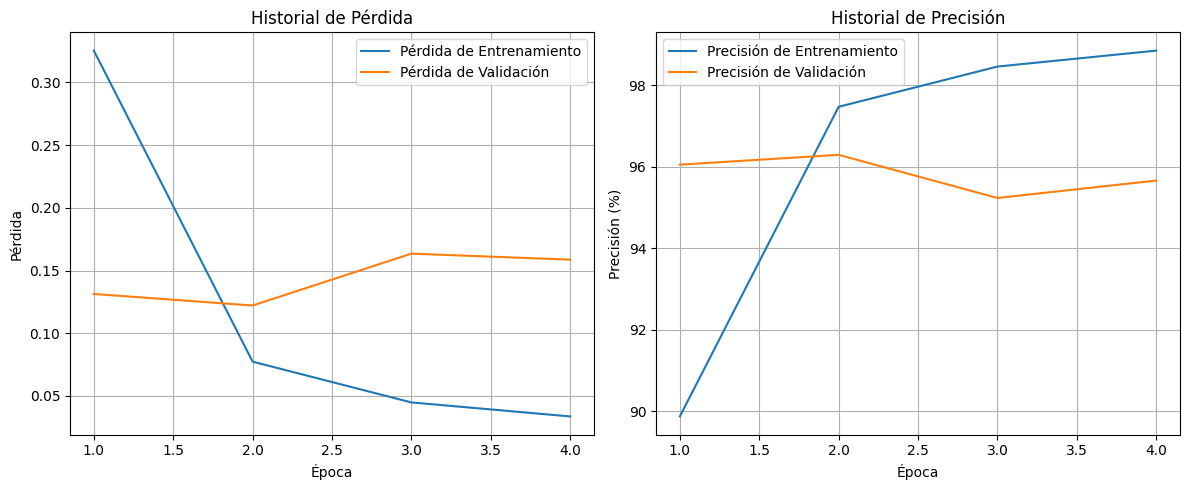

In [ ]:


# Listas para almacenar el historial de métricas
train_loss_history = []
train_accuracy_history = []
val_loss_history = []
val_accuracy_history = []

print("\nIniciando entrenamiento...")

# 'device' y 'model' ya están configurados globalmente para usar CUDA si está disponible en la celda b172b248.
# No es necesario redefinirlos aquí a menos que se quiera forzar un dispositivo específico.
# Se usará el 'device' que detectó la GPU (o CPU si no hay GPU).

# Añadir un intervalo de log para monitoreo en tiempo real
log_interval = 100 # Imprimir cada 100 lotes

# Parámetros para Early Stopping
patience = 2 # Número de épocas a esperar sin mejora en la pérdida de validación
min_delta = 0.001 # Cambio mínimo en la pérdida de validación para considerarlo una mejora
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train() # Poner el modelo en modo de entrenamiento
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Monitoreo dentro de la época
        if (i + 1) % log_interval == 0:
            print(f'    Época [{epoch+1}/{num_epochs}], Lote [{i+1}/{len(train_loader)}], ' +
                  f'Pérdida: {running_loss/(i+1):.4f}, Precisión: {100 * correct_train / total_train:.2f}%')

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train
    train_loss_history.append(train_loss)
    train_accuracy_history.append(train_accuracy)
    print(f"Época {epoch+1} Finalizada, Pérdida de Entrenamiento: {train_loss:.4f}, Precisión de Entrenamiento: {train_accuracy:.2f}%")

    # Evaluación en el conjunto de validación
    model.eval() # Poner el modelo en modo de evaluación
    correct_val = 0
    total_val = 0
    val_loss = 0.0
    with torch.no_grad(): # Desactivar el cálculo de gradientes
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    val_loss_history.append(val_loss)
    val_accuracy_history.append(val_accuracy)
    print(f"    Pérdida de Validación: {val_loss:.4f}, Precisión de Validación: {val_accuracy:.2f}%")

    # Lógica de Early Stopping
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Opcional: guardar el mejor modelo
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping activado después de {epoch+1} épocas sin mejora en la pérdida de validación.")
        break

print("\nEntrenamiento completado.")

# Graficar el historial de pérdida
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, label='Pérdida de Entrenamiento')
plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, label='Pérdida de Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Historial de Pérdida')
plt.legend()
plt.grid(True)

# Graficar el historial de precisión
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracy_history) + 1), train_accuracy_history, label='Precisión de Entrenamiento')
plt.plot(range(1, len(val_accuracy_history) + 1), val_accuracy_history, label='Precisión de Validación')
plt.xlabel('Época')
plt.ylabel('Precisión (%)')
plt.title('Historial de Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Modelo guardado exitosamente en: /content/drive/MyDrive/Colab Notebooks/TESIS/V1_ViT.pth


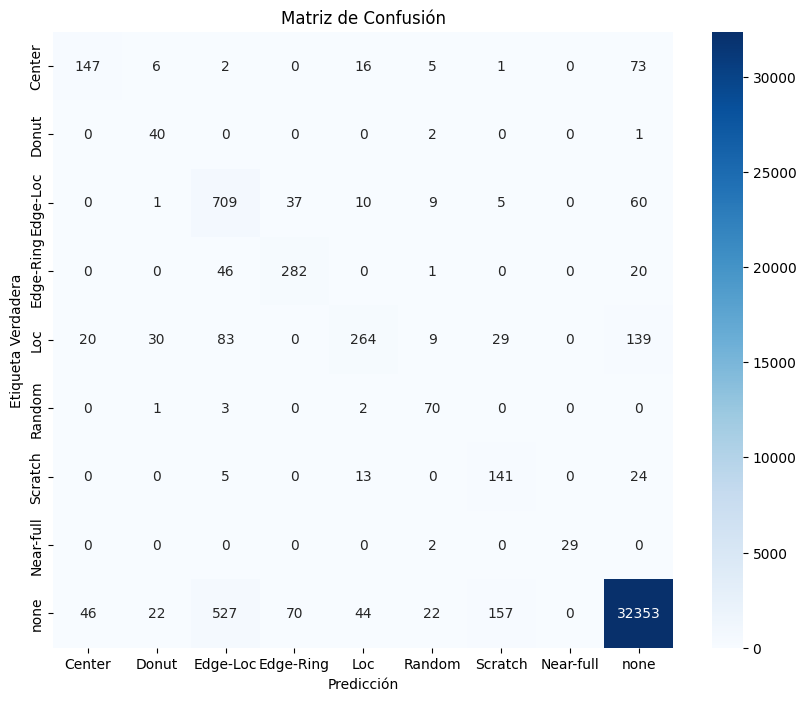


Informe de Clasificación:
               precision    recall  f1-score   support

      Center       0.69      0.59      0.63       250
       Donut       0.40      0.93      0.56        43
    Edge-Loc       0.52      0.85      0.64       831
   Edge-Ring       0.72      0.81      0.76       349
         Loc       0.76      0.46      0.57       574
      Random       0.58      0.92      0.71        76
     Scratch       0.42      0.77      0.55       183
   Near-full       1.00      0.94      0.97        31
        none       0.99      0.97      0.98     33241

    accuracy                           0.96     35578
   macro avg       0.68      0.80      0.71     35578
weighted avg       0.97      0.96      0.96     35578



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Guardar el modelo
model_path = "/content/drive/MyDrive/Colab Notebooks/TESIS/V1_ViT.pth" # Puedes ajustar la ruta donde quieres guardar el modelo
torch.save(model.state_dict(), model_path)
print(f"Modelo guardado exitosamente en: {model_path}")

# 2. Realizar pruebas para validar la calidad del modelo

# Asegurarse de que el modelo esté en modo de evaluación
model.eval()

all_labels = []
all_predictions = []

# Desactivar el cálculo de gradientes durante la evaluación
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Convertir listas a arrays de numpy
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# Generar la matriz de confusión
cm = confusion_matrix(all_labels, all_predictions)

# Obtener los nombres de las clases para la visualización
# `mapping_type` se definió en una celda anterior como {'Center':0, ..., 'none':8}
id_to_class = {v: k for k, v in mapping_type.items()}
class_names = [id_to_class[i] for i in range(len(mapping_type))]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()

# Generar informe de clasificación (Precision, Recall, F1-Score)
report = classification_report(all_labels, all_predictions, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación:\n", report)

# MODELO RESNET

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import time
from torchvision.models import resnet50, ResNet50_Weights

# 1. Cargar ResNet50 preentrenada en ImageNet
# Usamos el estándar de la industria para redes convolucionales profundas
weights = ResNet50_Weights.IMAGENET1K_V1
model_resnet = resnet50(weights=weights)

# 2. Modificar la última capa (Fully Connected - fc) para nuestras 9 clases
# ResNet50 tiene 2048 características de entrada en su última capa
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, 9)

# Mover el modelo a la GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_resnet = model_resnet.to(device)

print("Modelo ResNet50 cargado y modificado:")
print(f"Capa final: {model_resnet.fc}")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


Modelo ResNet50 cargado y modificado:
Capa final: Linear(in_features=2048, out_features=9, bias=True)


### Entrenamiento

Iniciando entrenamiento de ResNet50...

Época 1/5
--------------------
Train Loss: 0.0321 | Train Acc: 0.9740
Val Loss:   0.3476 | Val Acc:   0.9037

Época 2/5
--------------------
Train Loss: 0.0206 | Train Acc: 0.9811
Val Loss:   0.1961 | Val Acc:   0.9511

Época 3/5
--------------------
Train Loss: 0.0166 | Train Acc: 0.9838
Val Loss:   1.0361 | Val Acc:   0.7165
--> Sin mejora. Contador de Early Stopping: 1/2

Época 4/5
--------------------
Train Loss: 0.0361 | Train Acc: 0.9752
Val Loss:   0.4070 | Val Acc:   0.8959
--> Sin mejora. Contador de Early Stopping: 2/2
Early stopping activado

Entrenamiento completado en 21m 31s
Pesos óptimos cargados al modelo.


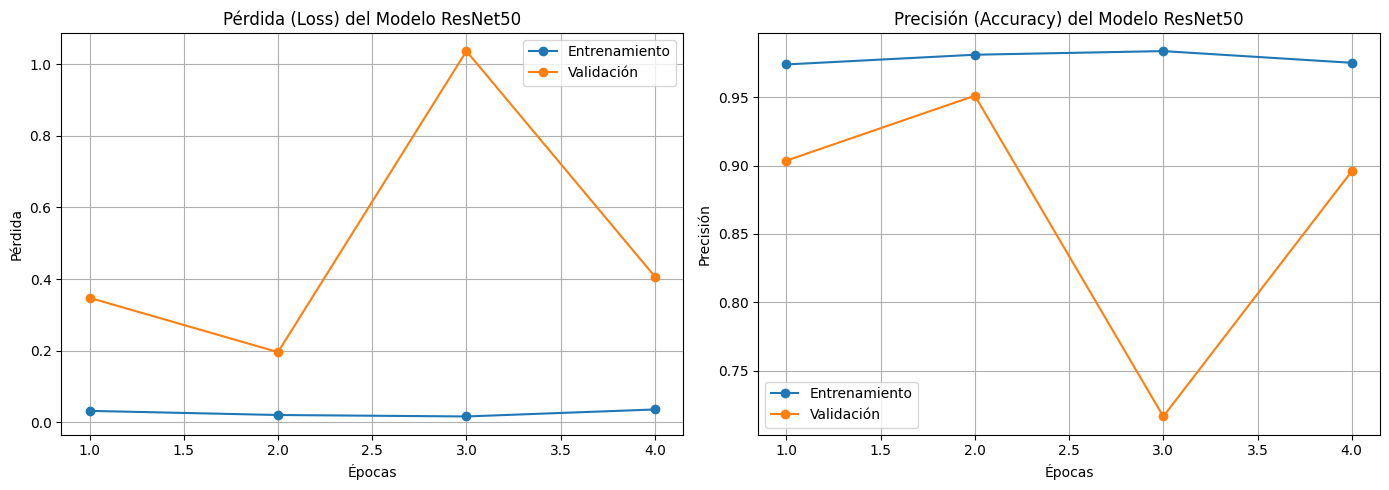

In [ ]:
# 3. Función de Pérdida (Usamos los MISMO PESOS que calculaste para el ViT)
# Asegúrate de que la variable 'pesos' ya esté calculada en tu notebook
criterion = nn.CrossEntropyLoss(weight=pesos)

# 4. Optimizador y Learning Rate
# OJO: Las ResNet son convolucionales (CNN) y son menos "delicadas" que los Transformers.
# Soportan un Learning Rate un poco más alto. Usaremos 1e-4 en lugar del 2e-5 del ViT.
optimizer = optim.AdamW(model_resnet.parameters(), lr=1e-4, weight_decay=1e-2)

# 5. Scheduler para reducir el Learning Rate si el modelo se estanca
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
num_epochs = 5  # Empezamos con 5, el early stopping lo detendrá si memoriza
best_model_wts = copy.deepcopy(model_resnet.state_dict())
best_val_loss = float('inf')
patience = 2  # Cuántas épocas esperar si la validación no mejora
epochs_no_improve = 0

# Diccionario para guardar el historial y graficar después
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("Iniciando entrenamiento de ResNet50...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nÉpoca {epoch+1}/{num_epochs}")
    print("-" * 20)

    # ==========================
    # FASE DE ENTRENAMIENTO
    # ==========================
    model_resnet.train()  # Poner el modelo en modo entrenamiento
    running_loss = 0.0
    running_corrects = 0
    total_train_samples = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # Limpiar gradientes anteriores

        # Forward pass (Hacer predicción)
        outputs = model_resnet(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        # Backward pass (Calcular errores y actualizar pesos)
        loss.backward()
        optimizer.step()

        # Acumular estadísticas
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train_samples += inputs.size(0)

    epoch_train_loss = running_loss / total_train_samples
    epoch_train_acc = running_corrects.double() / total_train_samples

    # ==========================
    # FASE DE VALIDACIÓN
    # ==========================
    model_resnet.eval()  # Poner el modelo en modo evaluación (apaga Dropout, etc.)
    val_running_loss = 0.0
    val_running_corrects = 0
    total_val_samples = 0

    with torch.no_grad(): # No calcular gradientes para ahorrar memoria
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model_resnet(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)
            total_val_samples += inputs.size(0)

    epoch_val_loss = val_running_loss / total_val_samples
    epoch_val_acc = val_running_corrects.double() / total_val_samples

    # Guardar en el historial
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc.item())
    history['val_acc'].append(epoch_val_acc.item())

    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")

    # Notificar al scheduler
    scheduler.step(epoch_val_loss)

    # ==========================
    # EARLY STOPPING Y GUARDADO
    # ==========================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model_resnet.state_dict())
        epochs_no_improve = 0
        torch.save(model_resnet.state_dict(), 'best_resnet50.pth')
    else:
        epochs_no_improve += 1
        print(f"--> Sin mejora. Contador de Early Stopping: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print("Early stopping activado")
        break

time_elapsed = time.time() - start_time
print(f"\nEntrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")

# Cargar los mejores pesos al modelo para usarlo en la matriz de confusión
model_resnet.load_state_dict(best_model_wts)
print("Pesos óptimos cargados al modelo.")

# ==========================
# VISUALIZACIÓN DE RESULTADOS
# ==========================
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Entrenamiento', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validación', marker='o')
plt.title('Pérdida (Loss) del Modelo ResNet50')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Entrenamiento', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validación', marker='o')
plt.title('Precisión (Accuracy) del Modelo ResNet50')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Asegurarse de que el modelo ResNet esté en modo de evaluación
model_resnet.eval()

all_labels_resnet = []
all_predictions_resnet = []

# Desactivar el cálculo de gradientes durante la evaluación
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_resnet(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels_resnet.extend(labels.cpu().numpy())
        all_predictions_resnet.extend(predicted.cpu().numpy())

# Convertir listas a arrays de numpy
all_labels_resnet = np.array(all_labels_resnet)
all_predictions_resnet = np.array(all_predictions_resnet)

# Generar la matriz de confusión
cm_resnet = confusion_matrix(all_labels_resnet, all_predictions_resnet)

# Obtener los nombres de las clases para la visualización
id_to_class = {v: k for k, v in mapping_type.items()}
class_names = [id_to_class[i] for i in range(len(mapping_type))]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_resnet, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión para ResNet50')
plt.show()

# Generar informe de clasificación (Precision, Recall, F1-Score)
report_resnet = classification_report(all_labels_resnet, all_predictions_resnet, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación para ResNet50:\n", report_resnet)


KeyboardInterrupt: 

# MODELO CNN BASICO

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=9):
        super(SimpleCNN, self).__init__()

        # Extractor de características (3 bloques convolucionales)
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # La imagen se reduce a 112x112

            # Bloque 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # La imagen se reduce a 56x56

            # Bloque 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # La imagen se reduce a 28x28
        )

        # Clasificador final
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5), # Evita el sobreajuste
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 1. Instanciar el modelo y enviarlo a la GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = SimpleCNN(num_classes=9).to(device)

# 2. Configurar Optimizador y Función de Pérdida (OJO: Asegúrate de tener la variable 'pesos' cargada)
# criterion = nn.CrossEntropyLoss(weight=pesos)
optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=1e-4, weight_decay=1e-2)

print("Modelo CNN Base armado")

Modelo CNN Base armado


In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=6c9ff89ea76ed65f7b8deb34d0df65ae9e9bfb004473ba0219a7040084378493
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


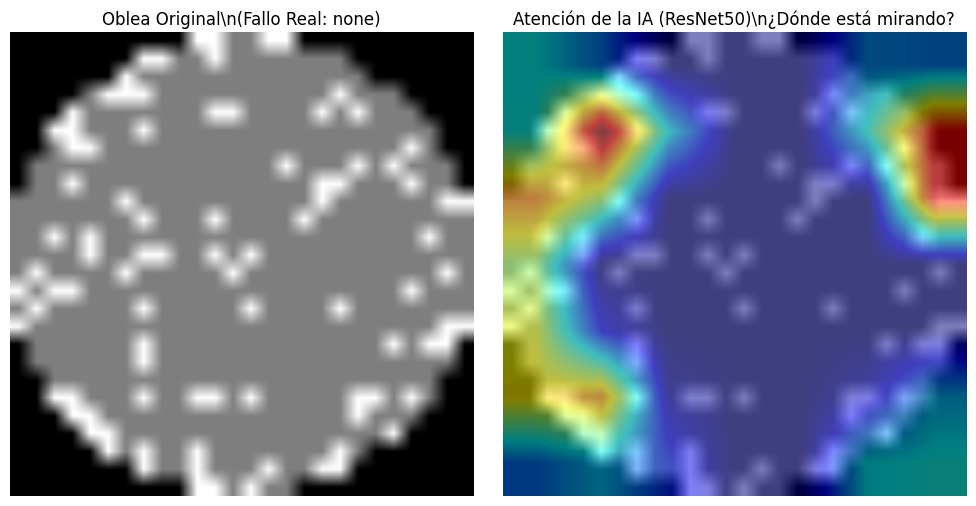

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# --- DICCIONARIO DE CLASES ---
# Asegúrate de que coincida con el orden de tus clases
id_to_class = {0: 'Center', 1: 'Donut', 2: 'Edge-Loc', 3: 'Edge-Ring',
               4: 'Loc', 5: 'Random', 6: 'Scratch', 7: 'Near-full', 8: 'none'}

# 1. Tomar UNA imagen de validación
model_resnet.eval()
inputs, labels = next(iter(val_loader))
input_tensor = inputs[0].unsqueeze(0).to(device)
etiqueta_real = labels[0].item()
nombre_clase = id_to_class[etiqueta_real]

# 2. Configurar Grad-CAM
target_layers = [model_resnet.layer4[-1]]
cam = GradCAM(model=model_resnet, target_layers=target_layers)
targets = [ClassifierOutputTarget(etiqueta_real)]

# 3. Generar la máscara de calor
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# 4. EL TRUCO VISUAL: Des-normalizar la imagen para que se vea clara
# Deshacemos la normalización de ImageNet matemáticamente
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_original = input_tensor[0].cpu().numpy().transpose(1, 2, 0)
img_original = std * img_original + mean
img_original = np.clip(img_original, 0, 1) # Aseguramos que los valores queden entre 0 y 1

# 5. Superponer el mapa de calor
# Reducimos un poco la opacidad del color (image_weight=0.5) para ver mejor la oblea abajo
visualizacion = show_cam_on_image(img_original, grayscale_cam, use_rgb=True, image_weight=0.5)

# ==========================================
# 6. DIBUJAR PANEL COMPARATIVO PARA LA TESIS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Izquierda: Oblea Original Clara
axes[0].imshow(img_original)
axes[0].set_title(f"Oblea Original\\n(Fallo Real: {nombre_clase})")
axes[0].axis('off')

# Derecha: Grad-CAM
axes[1].imshow(visualizacion)
axes[1].set_title(f"Atención de la IA (ResNet50)\\n¿Dónde está mirando?")
axes[1].axis('off')

plt.tight_layout()
plt.show()